In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial
import numpy as np

PDK.activate()

## MMI 2X2 (VÉRTICES)

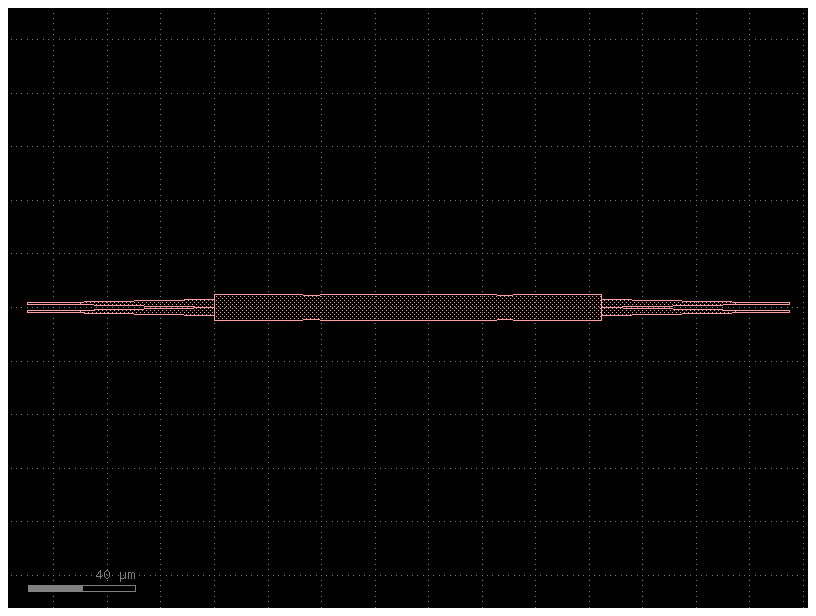

In [2]:
test  = cells.b_symmetric_mmi()
test.plot()

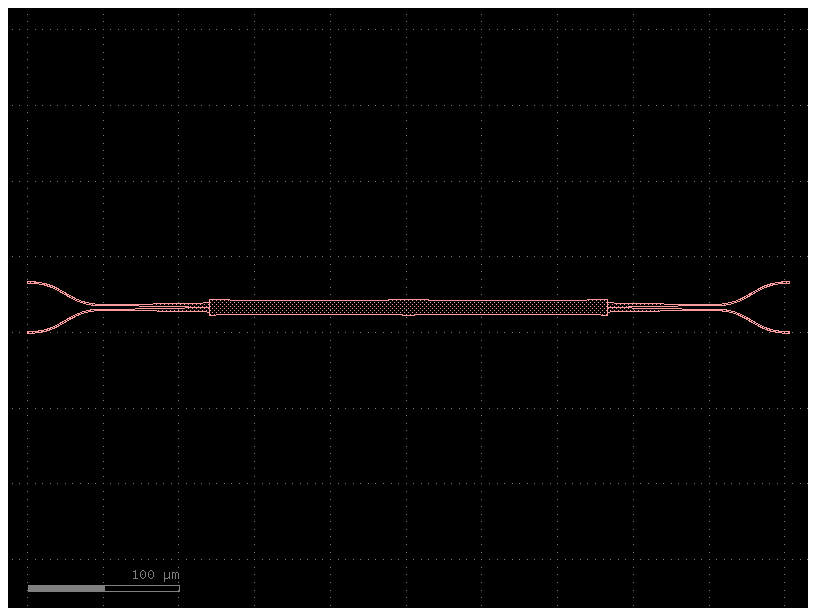

In [2]:
mmi95 = cells.mmi_2x2_bends()
mmi95.plot()

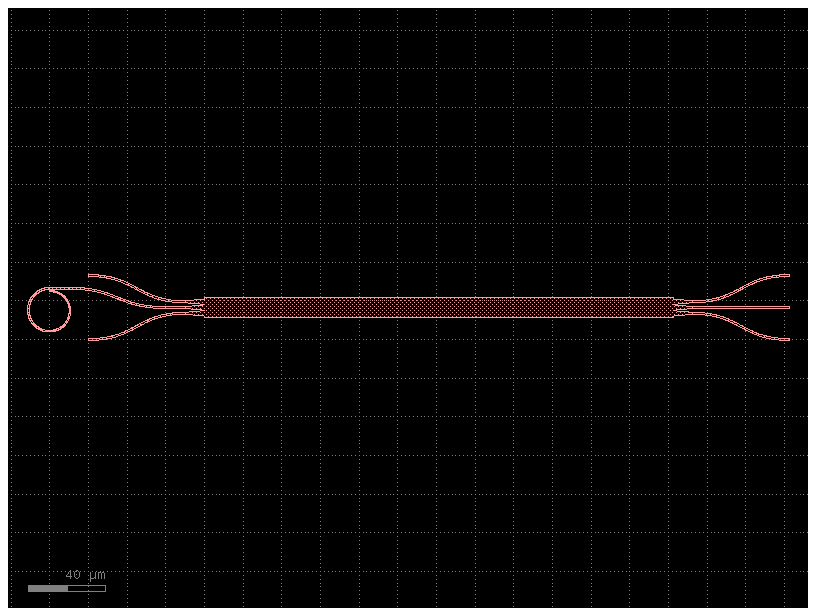

In [2]:
mmi33 = cells.mmi_3x3_test()
mmi33.plot()


2026-06-08 18:08:59.377 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3208593984.oas'


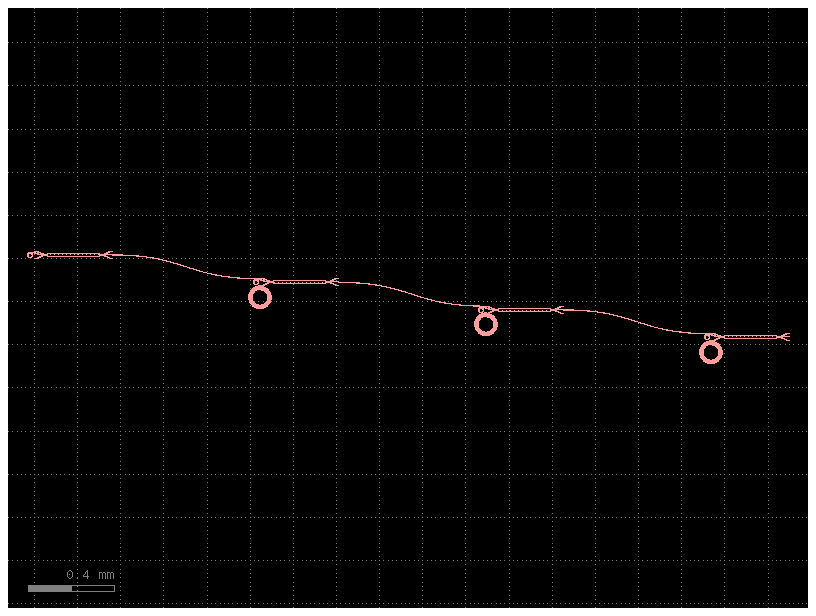

In [4]:
casc_A  = cells.mmi_ts(mmi33, 4500, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

## MMI TEST STRUCTURES 2X2

2026-06-08 15:35:55.621 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/1007440263.oas'


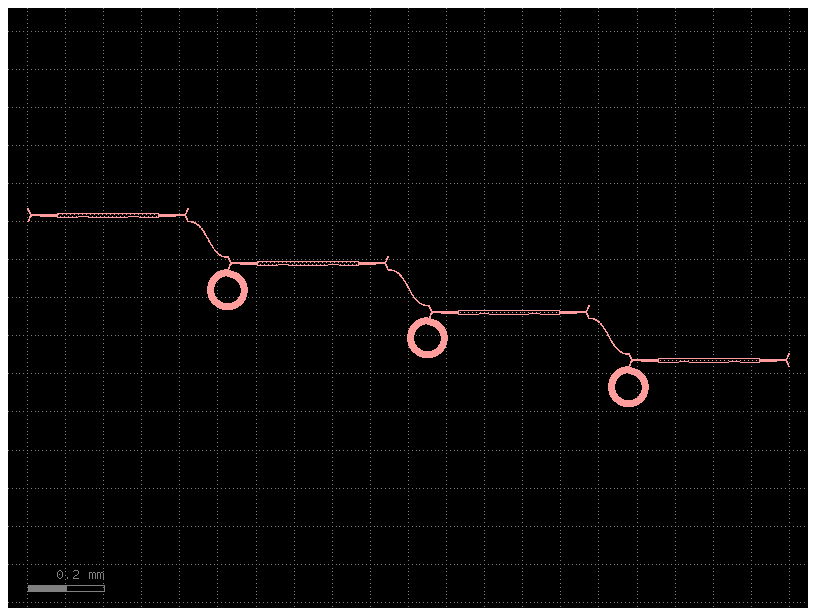

In [13]:
casc_A  = cells.mmi_ts(mmi95, 3000, 500, invert = True ,add_terminators=True)
casc_A.plot()
casc_A.show()

2026-06-08 15:42:24.462 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/2218000718.oas'


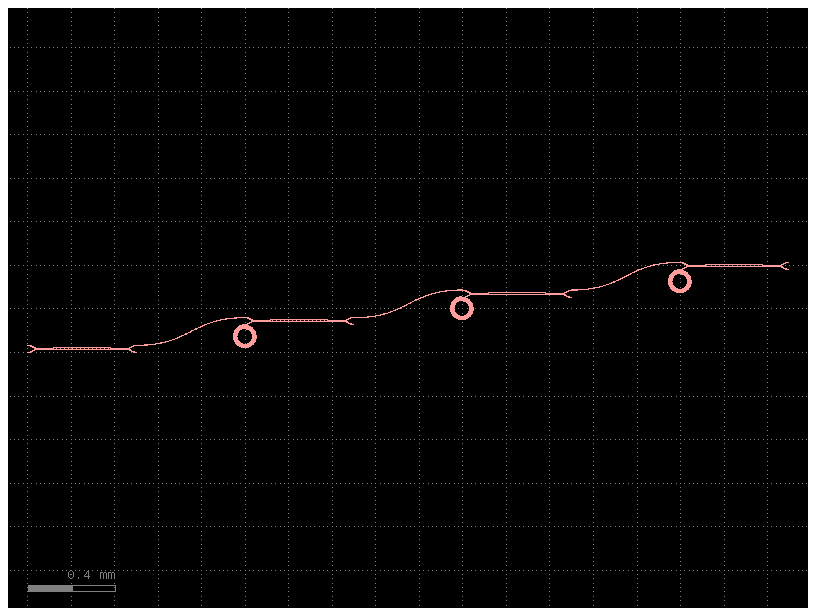

In [7]:
casc_B  = cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
casc_B.plot()
casc_B.show()

## WAVLENGTH TRACKER NUEVO

Defining spiral length for delay: 127958.636059777
Spiral length set to: 2220.00732421875
Spiral length 127958.64600000001
3100.0072026-06-09 20:51:44.827 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server



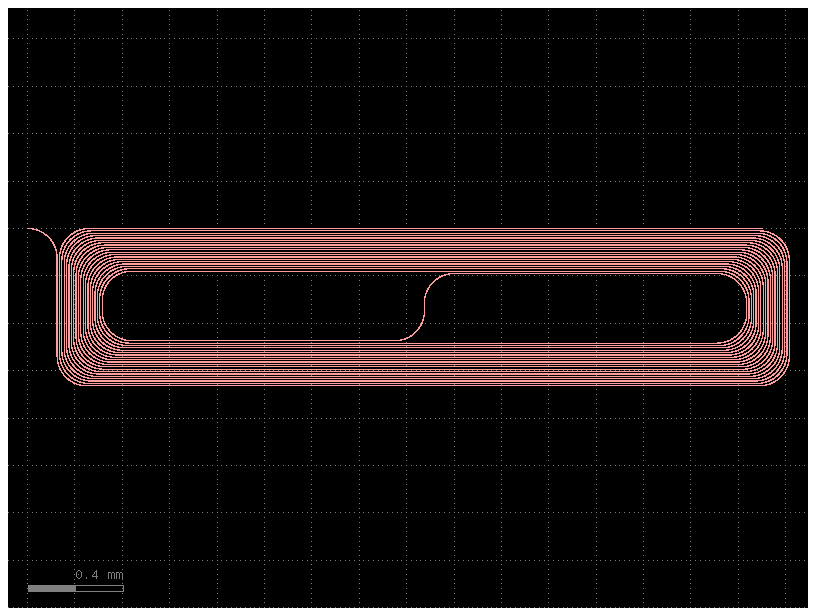

In [30]:
rad = 125
N_spr = 18
dy_spr = 33.76

L = 3100
AL = 124858.636059777

target_length =  L +AL # in microns 
#target_length = 56032.624

dx_length_spiral = cells.define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])
h = spiral.ports["o2"].dx - spiral.ports["o1"].dx
spiral.plot()
spiral.show()
print(h)

2026-06-09 20:59:11.863 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/404089563.oas'


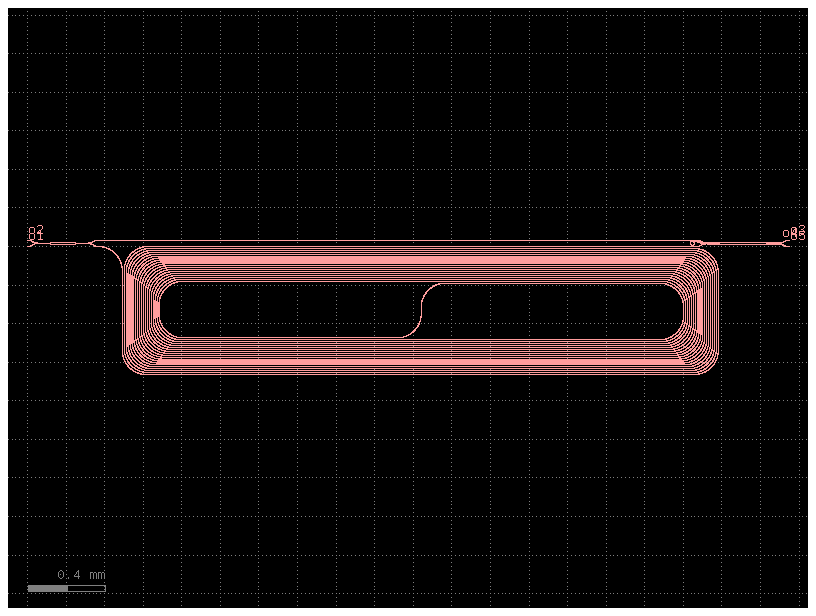

In [2]:
from upvfab.sin300.cband.tech import LAYER, TECH



test = cells.wvl_tracker_with_term()
test.draw_ports()
test.plot()
test.show()

3768.77932026-06-09 20:57:19.881 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/2909807908.oas'



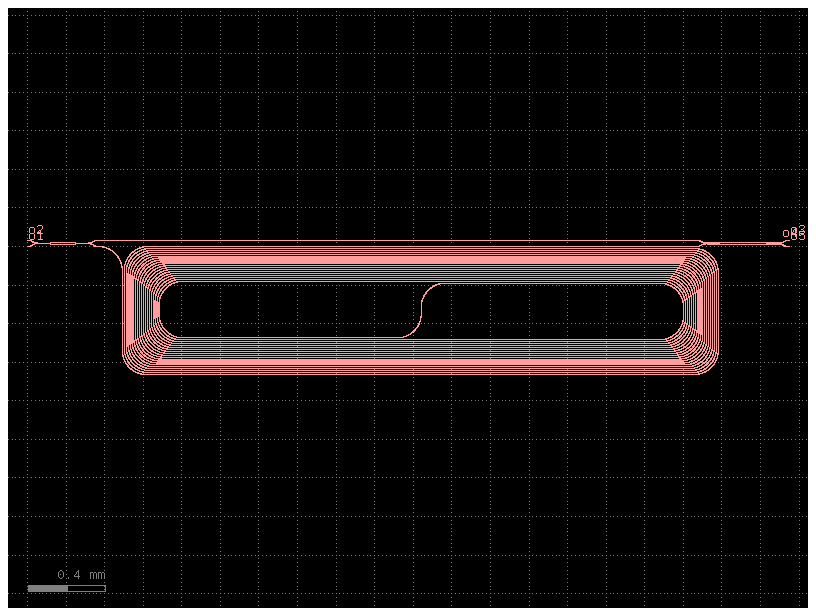

In [4]:
test = cells.wvl_tracker()
length = test.info["total_length_device"]
test.draw_ports()
test.plot()
test.show()
print(length)

## CASCADAS MMI 3X3

2026-06-09 16:42:01.882 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3385568247.oas'


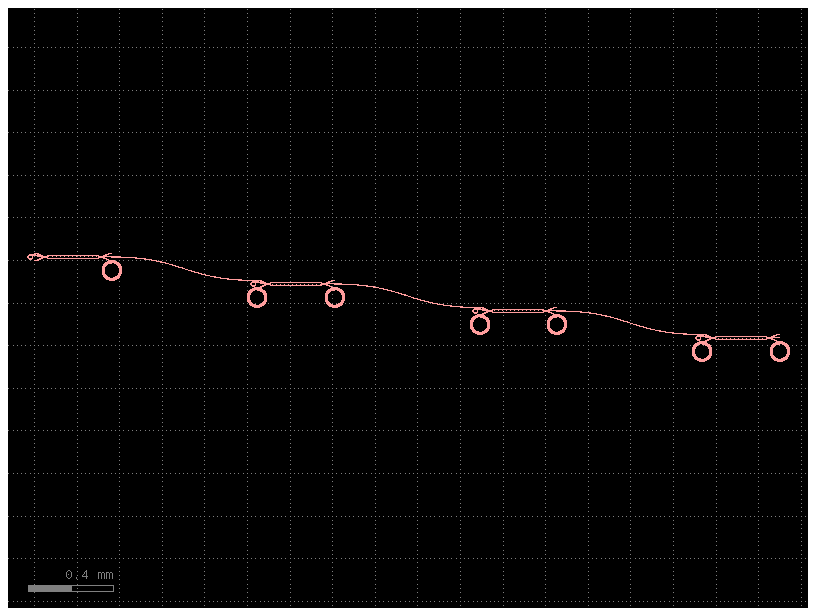

In [3]:

test = cells.dummy_2x2(21)
n21 = cells.mmi_ts(test, 4500, 500, invert = True ,add_terminators=True, mirror_terminators= False)
n21.plot()
n21.show()


2026-06-08 20:47:01.443 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/1380053940.oas'


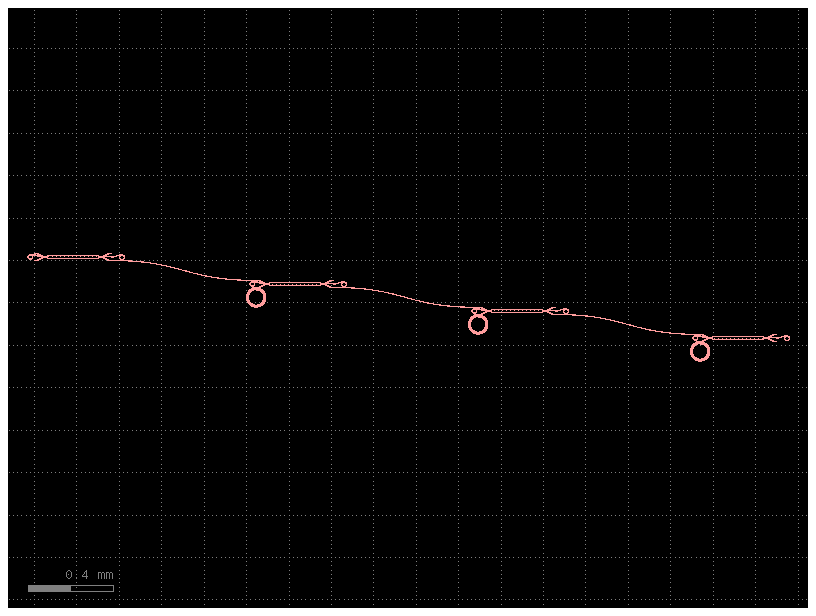

In [3]:

test = cells.dummy_2x2(31)
n31 = cells.mmi_ts(test, 4500, 500, invert = True ,add_terminators=True, mirror_terminators= False)
n31.plot()
n31.show()


2026-06-08 20:48:29.686 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3430668525.oas'


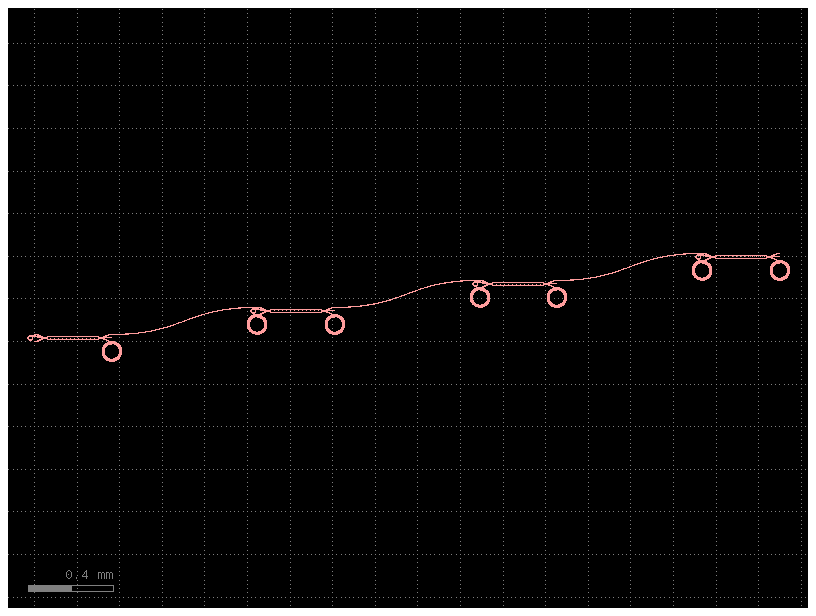

In [5]:
test = cells.dummy_2x2(11)
n11 = cells.mmi_ts(test, 4500, 500, invert = False ,add_terminators=True, mirror_terminators= False)
n11.plot()
n11.show()

2026-06-08 20:48:57.460 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/TFG/build/oas/3355096757.oas'


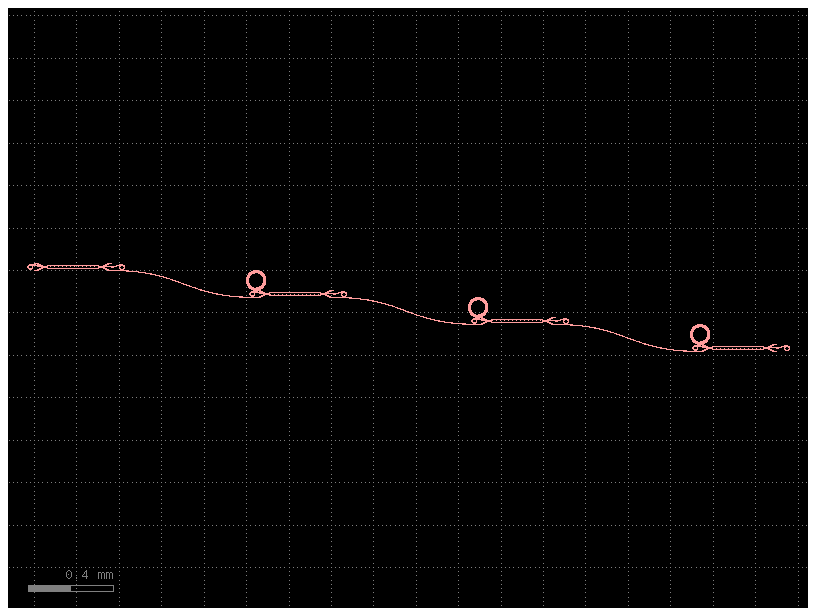

In [6]:
test = cells.dummy_2x2(33)
n33 = cells.mmi_ts(test, 4500, 500, invert = True ,add_terminators=True, mirror_terminators= True)
n33.plot()
n33.show()

2026-06-08 20:49:43.857 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/2026093254.oas'


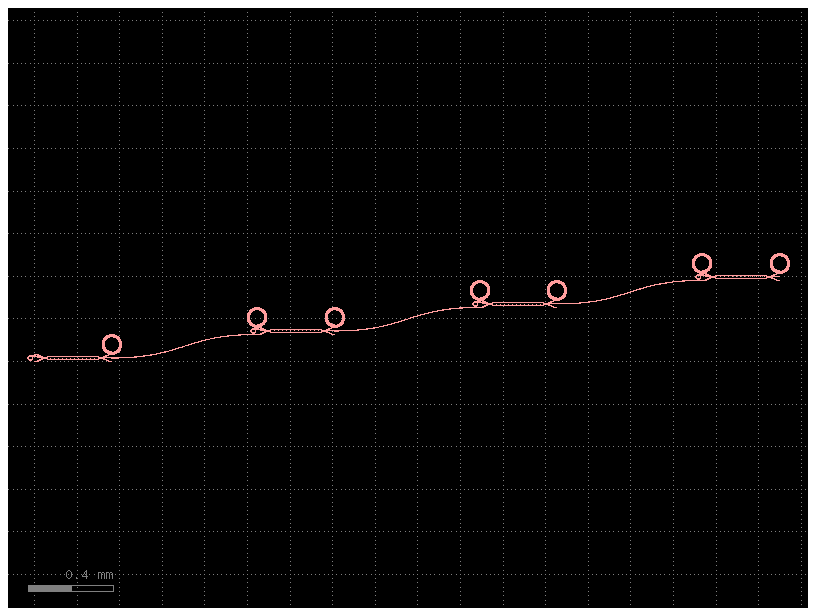

In [7]:
test = cells.dummy_2x2(32)
n32 = cells.mmi_ts(test, 4500, 500, invert = False ,add_terminators=True, mirror_terminators= True)
n32.plot()
n32.show()

# CHIP

2026-06-09 21:00:33.557 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/1763829505.oas'


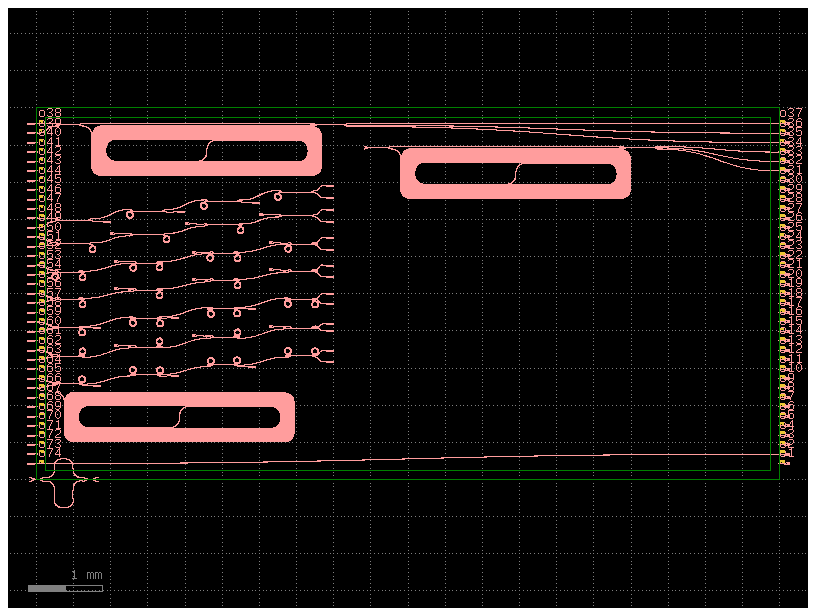

In [3]:
chip = gf.Component()
altura_cto = 713.5
altura_casc = 505
border = 125
grat_dx = 142.73
cto = cells.wvl_tracker_with_term()
length = cto.info["total_length_device"]

die = chip << cells.die_with_gratings(ngratings=37, grating_pitch = 127, edge_to_grating_distance= -125)
dist_grat_dy = die.ports['o74'].dy - die.ports['o73'].dy
dist_grat_dx = np.abs(die.ports['o74'].dx - die.ports['o1'].dx)

cto_1 = chip << cells.wvl_tracker_with_term()
cto_2 = chip << cells.wvl_tracker_with_term()
mmi95 = cells.mmi_2x2_bends()
casc_A_1  = chip << cells.mmi_ts(mmi95, 4500, 500, invert = True ,add_terminators= True)
pitch_casc = casc_A_1.ports['o3'].dy - casc_A_1.ports['o4'].dy
length_cascada = np.abs(casc_A_1.ports['o1'].dx - casc_A_1.ports['o6'].dx)
casc_B_1  = chip << cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
spiral_1 = chip << cells.spiral_upv(radius = 125, N_spr = 18 , d_SPR =10 , dx_SPR= 2220.00732421875, dy_SPR = 33.76, layer = "strip")
gc_casc_B = [chip << cells.grating_coupler_rectangular() for _ in range(5)]
gc_casc_A = [chip << cells.grating_coupler_rectangular() for _ in range(5)]
gc_n21 = [chip << cells.grating_coupler_rectangular() for _ in range(5)]
gc_n31 = [chip << cells.grating_coupler_rectangular() for _ in range(5)]
gc_n11 = [chip << cells.grating_coupler_rectangular() for _ in range(5)]
gc_n33 = [chip << cells.grating_coupler_rectangular() for _ in range(5)]
gc_n23 = [chip << cells.grating_coupler_rectangular() for _ in range(5)]

n21 = chip << cells.mmi_ts(cells.dummy_2x2(21), 4500, 500, invert = True ,add_terminators=True, mirror_terminators= False)
n31 = chip << cells.mmi_ts(cells.dummy_2x2(31), 4500, 500, invert = True ,add_terminators=True, mirror_terminators= False)
n11 = chip << cells.mmi_ts(cells.dummy_2x2(11), 4500, 500, invert = False ,add_terminators=True, mirror_terminators= False)
n33 = chip << cells.mmi_ts(cells.dummy_2x2(33), 4500, 500, invert = True ,add_terminators=True, mirror_terminators= True)
n23 = chip << cells.mmi_ts(cells.dummy_2x2(23), 4500, 500, invert = False ,add_terminators=True, mirror_terminators= True)

g = chip << cells.mzi(delta_length=200)

#posiciones

cto_1.dmove((250, 4750))
cto_2.dmove((cto_1.ports['o4'].dx + 250, cto_1.ports['o4'].dy - 320))
casc_B_1.dmove((cto_1.ports['o1'].dx, cto_1.ports['o1'].dy - 2*altura_cto +150))
gc_casc_B[0].dmove((casc_B_1.ports['o3'].dx + 100, casc_B_1.ports['o3'].dy))
gc_casc_B[1].dmove((casc_B_1.ports['o4'].dx + 100, casc_B_1.ports['o4'].dy))
gc_casc_B[2].dmove((casc_B_1.ports['o5'].dx + 100, casc_B_1.ports['o5'].dy))
gc_casc_B[3].dmove((casc_B_1.ports['o6'].dx + 100, casc_B_1.ports['o6'].dy - dist_grat_dy/2 )) 
gc_casc_B[4].dmove((casc_B_1.ports['o7'].dx + 100, casc_B_1.ports['o7'].dy +  dist_grat_dy/2))
casc_A_1.dmirror_x()
casc_A_1.dmove((cto_1.ports['o1'].dx + length_cascada, cto_1.ports['o1'].dy - altura_cto - altura_casc ))
for i in range(3): 
    gc_casc_A[i].dmirror_x()
gc_casc_A[0].dmove((casc_A_1.ports['o3'].dx - 100, casc_A_1.ports['o3'].dy))
gc_casc_A[1].dmove((casc_A_1.ports['o4'].dx - 100, casc_A_1.ports['o4'].dy))
gc_casc_A[2].dmove((casc_A_1.ports['o5'].dx - 100, casc_A_1.ports['o5'].dy))
gc_casc_A[3].dmove((casc_A_1.ports['o1'].dx  + 100, casc_A_1.ports['o1'].dy + dist_grat_dy/2 )) 
gc_casc_A[4].dmove((casc_A_1.ports['o2'].dx +  100, casc_A_1.ports['o2'].dy - dist_grat_dy/2 ))

n21.dmirror_x()
n21.dmove((casc_A_1.ports['o6'].dx + length_cascada, casc_A_1.ports['o6'].dy))
for i in range(3): 
    gc_n21[i].dmirror_x()
gc_n21[0].dmove((n21.ports['o3'].dx - 100, n21.ports['o3'].dy))
gc_n21[1].dmove((n21.ports['o4'].dx - 100, n21.ports['o4'].dy))
gc_n21[2].dmove((n21.ports['o5'].dx - 100, n21.ports['o5'].dy))
gc_n21[3].dmove((n21.ports['o1'].dx  + 100, n21.ports['o1'].dy + dist_grat_dy/2 )) 
gc_n21[4].dmove((n21.ports['o2'].dx +  100, n21.ports['o2'].dy - dist_grat_dy/2))
n31.dmirror_x()
n31.dmove((n21.ports['o6'].dx + length_cascada, n21.ports['o6'].dy))
for i in range(3): 
    gc_n31[i].dmirror_x()
gc_n31[0].dmove((n31.ports['o3'].dx - 100, n31.ports['o3'].dy))
gc_n31[1].dmove((n31.ports['o4'].dx - 100, n31.ports['o4'].dy))
gc_n31[2].dmove((n31.ports['o5'].dx - 100, n31.ports['o5'].dy))
gc_n31[3].dmove((n31.ports['o1'].dx  + 100, n31.ports['o1'].dy + dist_grat_dy/2 )) 
gc_n31[4].dmove((n31.ports['o2'].dx +  100, n31.ports['o2'].dy - dist_grat_dy/2))
n11.dmove((n31.ports['o6'].dx, n31.ports['o6'].dy - 3*altura_casc/4))
gc_n11[0].dmove((n11.ports['o3'].dx + 100, n11.ports['o3'].dy))
gc_n11[1].dmove((n11.ports['o4'].dx + 100, n11.ports['o4'].dy))
gc_n11[2].dmove((n11.ports['o5'].dx + 100, n11.ports['o5'].dy))
gc_n11[3].dmove((n11.ports['o6'].dx + 100, n11.ports['o6'].dy - dist_grat_dy/2 )) 
gc_n11[4].dmove((n11.ports['o7'].dx + 100, n11.ports['o7'].dy +  dist_grat_dy/2))
n33.dmirror_x()
n33.dmove((n11.ports['o1'].dx + length_cascada, n11.ports['o1'].dy))
for i in range(3): 
    gc_n33[i].dmirror_x()
gc_n33[0].dmove((n33.ports['o3'].dx - 100, n33.ports['o3'].dy))
gc_n33[1].dmove((n33.ports['o4'].dx - 100, n33.ports['o4'].dy))
gc_n33[2].dmove((n33.ports['o5'].dx - 100, n33.ports['o5'].dy))
gc_n33[3].dmove((n33.ports['o1'].dx  + 100, n33.ports['o1'].dy + dist_grat_dy/2 )) 
gc_n33[4].dmove((n33.ports['o2'].dx +  100, n33.ports['o2'].dy - dist_grat_dy/2))
n23.dmove((n33.ports['o6'].dx, n33.ports['o6'].dy - 3*altura_casc/4))
gc_n23[0].dmove((n23.ports['o3'].dx + 100, n23.ports['o3'].dy))
gc_n23[1].dmove((n23.ports['o4'].dx + 100, n23.ports['o4'].dy))
gc_n23[2].dmove((n23.ports['o5'].dx + 100, n23.ports['o5'].dy))
gc_n23[3].dmove((n23.ports['o6'].dx + 100, n23.ports['o6'].dy - dist_grat_dy/2 )) 
gc_n23[4].dmove((n23.ports['o7'].dx + 100, n23.ports['o7'].dy +  dist_grat_dy/2))


spiral_1.dmove((n23.ports['o1'].dx, n23.ports['o1'].dy + dist_grat_dy))

#conexiones
#cto_1
gf.routing.route_single_sbend(chip, port1=die.ports['o38'], port2=cto_1.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o39'], port2=cto_1.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=cto_1.ports['o3'], port2=die.ports['o37'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=cto_1.ports['o4'], port2=die.ports['o36'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=cto_1.ports['o5'], port2=die.ports['o35'], cross_section="strip")

#cto_2 (cruza por el cto uno, pongo gratings en cto 2?)
#gf.routing.route_single_sbend(chip, port1=die.ports['o40'], port2=cto_2.ports['o2'], cross_section="strip")
#gf.routing.route_single_sbend(chip, port1=die.ports['o41'], port2=cto_2.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=cto_2.ports['o3'], port2=die.ports['o34'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=cto_2.ports['o4'], port2=die.ports['o33'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=cto_2.ports['o5'], port2=die.ports['o32'], cross_section="strip")

#cascadas 1 (mmi 2x2)
##cascada B (1-k)
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o3'], port2=gc_casc_B[0].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o4'], port2=gc_casc_B[1].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o5'], port2=gc_casc_B[2].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o6'], port2=gc_casc_B[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o7'], port2=gc_casc_B[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o48'], port2=casc_B_1.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o49'], port2=casc_B_1.ports['o1'], cross_section="strip")
##cascada A (k)
gf.routing.route_single_sbend(chip, port1=gc_casc_A[0].ports['o1'], port2=casc_A_1.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_casc_A[1].ports['o1'], port2=casc_A_1.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_casc_A[2].ports['o1'], port2=casc_A_1.ports['o5'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o1'], port2=gc_casc_A[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o2'], port2=gc_casc_A[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o50'], port2=casc_A_1.ports['o7'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o51'], port2=casc_A_1.ports['o6'], cross_section="strip")

#cascadas 1 (mmi 3x3)
##n21
gf.routing.route_single_sbend(chip, port1=gc_n21[0].ports['o1'], port2=n21.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_n21[1].ports['o1'], port2=n21.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_n21[2].ports['o1'], port2=n21.ports['o5'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n21.ports['o1'], port2=gc_n21[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n21.ports['o2'], port2=gc_n21[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o53'], port2=n21.ports['o7'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o54'], port2=n21.ports['o6'], cross_section="strip")

##n31
gf.routing.route_single_sbend(chip, port1=gc_n31[0].ports['o1'], port2=n31.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_n31[1].ports['o1'], port2=n31.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_n31[2].ports['o1'], port2=n31.ports['o5'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n31.ports['o1'], port2=gc_n31[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n31.ports['o2'], port2=gc_n31[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o56'], port2=n31.ports['o7'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o57'], port2=n31.ports['o6'], cross_section="strip")

##n11
gf.routing.route_single_sbend(chip, port1=n11.ports['o3'], port2=gc_n11[0].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n11.ports['o4'], port2=gc_n11[1].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n11.ports['o5'], port2=gc_n11[2].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n11.ports['o6'], port2=gc_n11[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n11.ports['o7'], port2=gc_n11[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o59'], port2=n11.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o60'], port2=n11.ports['o1'], cross_section="strip")

##n33
gf.routing.route_single_sbend(chip, port1=gc_n33[0].ports['o1'], port2=n33.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_n33[1].ports['o1'], port2=n33.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=gc_n33[2].ports['o1'], port2=n33.ports['o5'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n33.ports['o1'], port2=gc_n33[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n33.ports['o2'], port2=gc_n33[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o62'], port2=n33.ports['o7'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o63'], port2=n33.ports['o6'], cross_section="strip")

##n11
gf.routing.route_single_sbend(chip, port1=n23.ports['o3'], port2=gc_n23[0].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n23.ports['o4'], port2=gc_n23[1].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n23.ports['o5'], port2=gc_n23[2].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n23.ports['o6'], port2=gc_n23[3].ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=n23.ports['o7'], port2=gc_n23[4].ports['o1'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=die.ports['o65'], port2=n23.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=die.ports['o66'], port2=n23.ports['o2'], cross_section="strip")

# bottom waveguides

gf.routing.route_single_sbend(chip, port1=die.ports['o74'], port2=die.ports['o2'], cross_section="strip")






chip.add_ports(die)
chip.draw_ports()
chip.plot()
chip.show()

2026-06-09 16:57:06.634 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/832335559.oas'


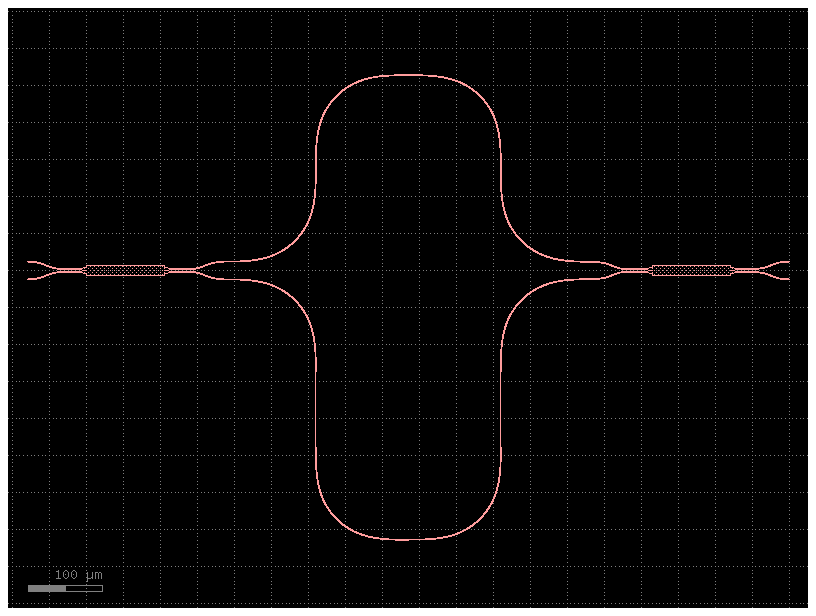

In [2]:
g = cells.mzi(delta_length=200, splitter = "mmi2x2_c")
g.plot()
g.show()

# CHIP ANTERIOR

2026-06-08 17:14:47.194 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


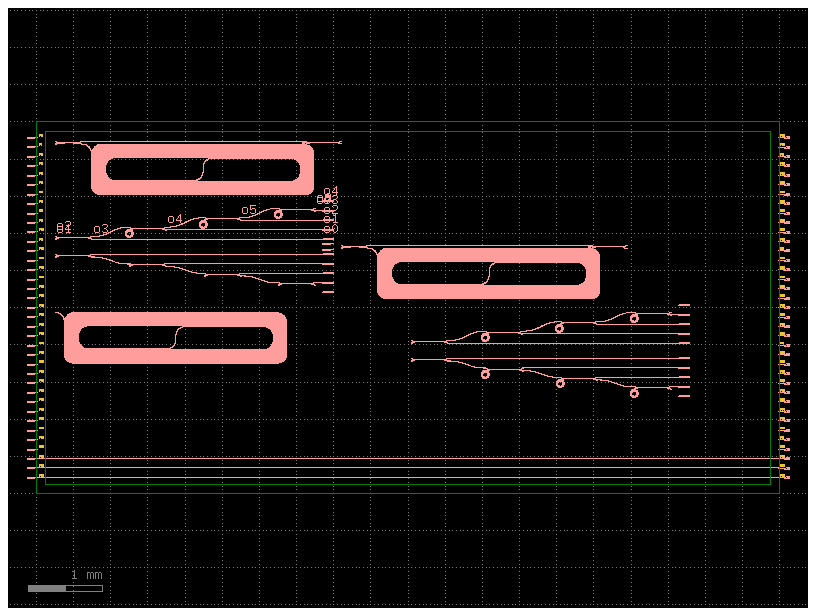

In [11]:
chip = gf.Component()
altura_cto = 713.5
altura_casc = 505
border = 125
grat_dx = 142.73
cto = cells.wvl_tracker_with_term()
length = cto.info["total_length_device"]

die = chip << cells.die_with_gratings(ngratings=37, grating_pitch = 127, edge_to_grating_distance= -125)
dist_grat_dy = die.ports['o74'].dy - die.ports['o73'].dy
dist_grat_dx = np.abs(die.ports['o74'].dx - die.ports['o1'].dx)

cto_1 = chip << cells.wvl_tracker_with_term()
cto_2 = chip << cells.wvl_tracker_with_term()
casc_A_1  = chip << cells.mmi_ts(mmi95, 4500, 500, invert = True ,add_terminators=False)
pitch_casc = casc_A_1.ports['o3'].dy - casc_A_1.ports['o4'].dy
casc_B_1  = chip << cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
spiral_1 = chip << cells.spiral_upv(radius = 125, N_spr = 18 , d_SPR =10 , dx_SPR= 2120.00732421875, dy_SPR = 50.46, layer = "strip")
casc_A_2  = chip << cells.mmi_ts(mmi95, 4500, 500, invert = True ,add_terminators=True)
casc_B_2  = chip << cells.mmi_ts(mmi95, 4500, 500,  add_terminators=True)
wvg = gf.components.straight(dist_grat_dx)
bottom_wvg = chip << gf.components.array(component = wvg, columns = 1, rows = 3, row_pitch = dist_grat_dy)
gca = gf.c.grating_coupler_array(n=5, pitch=pitch_casc, with_loopback=False, grating_coupler= 'grating_coupler_rectangular')
gca_cto = gf.c.grating_coupler_array(n=2, pitch=80, with_loopback=False, grating_coupler= 'grating_coupler_rectangular')
gca_cB_1 = chip << gca
gca_cA_1 = chip << gca
gca_cB_2 = chip << gca
gca_cA_2 = chip << gca
gca_cto_2_in = chip << gca_cto


#posiciones

cto_1.dmove((250, 4700))
casc_B_1.dmove((cto_1.ports['o1'].dx, cto_1.ports['o1'].dy - 2*altura_cto + 150))
casc_A_1.dmove((cto_1.ports['o1'].dx, cto_1.ports['o1'].dy - altura_cto - altura_casc -300))
gca_cB_1.rotate(90)
gca_cB_1.dmove((casc_B_1.ports['o7'].dx +100, casc_B_1.ports['o5'].dy))
gca_cto_2_in.rotate(-90)
gca_cto_2_in.dmove((casc_B_1.ports['o7'].dx + 100 + grat_dx, casc_B_1.ports['o1'].dy + dist_grat_dy/2 -40 ))
cto_2.dmove((gca_cto_2_in.ports['o0'].dx +100 , gca_cto_2_in.ports['o0'].dy -60))
gca_cA_1.rotate(90)
gca_cA_1.dmove((casc_A_1.ports['o7'].dx +100, casc_A_1.ports['o5'].dy))

spiral_1.dmove((cto_1.ports['o1'].dx, cto_2.ports['o1'].dy - altura_cto - 150))
casc_B_2.dmove((cto_2.ports['o1'].dx + 950, cto_2.ports['o1'].dy - 2*altura_cto + 150))
casc_A_2.dmove((cto_2.ports['o1'].dx + 950, cto_2.ports['o1'].dy - altura_cto - altura_casc -300))
gca_cB_2.rotate(90)
gca_cB_2.dmove((casc_B_2.ports['o7'].dx +100, casc_B_2.ports['o5'].dy))
gca_cA_2.rotate(90)
gca_cA_2.dmove((casc_A_2.ports['o7'].dx +100, casc_A_2.ports['o5'].dy))
bottom_wvg.dmove((die.ports['o72'].dx , die.ports['o72'].dy))

#conexiones

#cascada 1
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o3'], port2=gca_cB_1.ports['o0'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o4'], port2=gca_cB_1.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o5'], port2=gca_cB_1.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o7'], port2=gca_cB_1.ports['o3'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_B_1.ports['o6'], port2=gca_cB_1.ports['o4'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o3'], port2=gca_cA_1.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o4'], port2=gca_cA_1.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o5'], port2=gca_cA_1.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o7'], port2=gca_cA_1.ports['o1'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_A_1.ports['o6'], port2=gca_cA_1.ports['o0'], cross_section="strip")

#cascada 2

gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o3'], port2=gca_cB_2.ports['o0'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o4'], port2=gca_cB_2.ports['o1'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o5'], port2=gca_cB_2.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o7'], port2=gca_cB_2.ports['o3'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_B_2.ports['o6'], port2=gca_cB_2.ports['o4'], cross_section="strip")

gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o3'], port2=gca_cA_2.ports['o4'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o4'], port2=gca_cA_2.ports['o3'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o5'], port2=gca_cA_2.ports['o2'], cross_section="strip")
gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o7'], port2=gca_cA_2.ports['o1'], cross_section="strip")
# gf.routing.route_single_sbend(chip, port1=casc_A_2.ports['o6'], port2=gca_cA_2.ports['o0'], cross_section="strip")




#chip.add_ports(die)
chip.add_ports(casc_B_1)
chip.add_ports(gca_cB_1)
chip.draw_ports()
chip.plot()
chip.show()